In [1]:
import os 
import torch 
import numpy as np 
import random
import pandas as pd

from matplotlib import pyplot as plt 

plt.rcParams["font.family"] = "Helvetica"

In [2]:
data_dir = "./perturb-cite-seq"

condition = "cocult"

condition_dir = os.path.join(data_dir, condition)

In [3]:
os.chdir("../")

print("Currently in {}".format(os.getcwd()))


Currently in /Users/alparturkoglu/Desktop/SCOUT/SCOUT-master


In [4]:
training_datasets = [
    np.load(os.path.join(condition_dir + "/training_data", f"dataset-{i}.npy"))
    for i in range(55)
]

validation_datasets = [
    np.load(os.path.join(condition_dir + "/validation_data", f"dataset-{i}.npy")) for i in range(6)
]

In [5]:
tot_dataset = training_datasets + validation_datasets

# centering the data
tot_dataset_centered = list()
for dataset in tot_dataset:
    dataset_centered = dataset - dataset.mean(axis=0)
    tot_dataset_centered.append(dataset_centered)

chosen_genes = list(range(61))
total_datasets = [tot_dataset_centered[i][:, chosen_genes] for i in chosen_genes]
total_interventions = [[i] for i in range(len(total_datasets))]

In [6]:
combined = list(zip(total_interventions, total_datasets))
random.shuffle(combined)

shuffled_interventions, shuffled_datasets = zip(*combined)

n_valid_data = 6

training_intervention_sets = shuffled_interventions[:-n_valid_data]
training_dataset_centered = shuffled_datasets[:-n_valid_data]

validation_dataset_centered = shuffled_datasets[-n_valid_data:]
validation_intervention_sets = shuffled_interventions[-n_valid_data:]

In [7]:
genes = pd.read_csv(os.path.join(data_dir, "genes.csv"))


OUR MODEL

In [8]:
from models.scout_trainer import scout_train_test_wrapper
model = scout_train_test_wrapper(
    n_nodes=61,
    batch_size=512,
    l1_reg=True, 
    lambda_c=1e-3,
    lambda_r=1e-2, # sparsity penalization coef
    fun_type='gst-mlp', # Gumble-softmax masking function
    act_fun='tanh',
    lr=1e-2,
    epochs=100, # change to a higher number for better accuracy,
    v=True, 
    inline=True, 
    n_hidden=0,
    optim='adam',
    n_experiments=len(training_intervention_sets),
)


Initializing the model
Number of Parameters : 20803


In [ ]:
model.train(
    training_dataset_centered,
    training_intervention_sets,
)

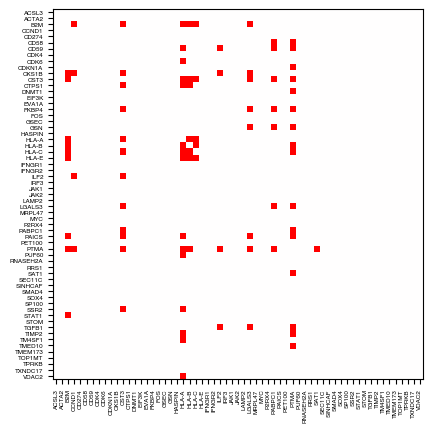

In [ ]:
fig, axs = plt.subplots(1)

axs.imshow(model.model.return_adjacency().detach().cpu().numpy() > 0.1, cmap="bwr", vmin=-1, vmax=1)

axs.set_xticks(range(61))
_ = axs.set_yticks(range(61))
_ = axs.set_xticklabels(genes["Genes"], rotation=90, fontsize=4.5)
_ = axs.set_yticklabels(genes["Genes"], fontsize=4.5)

fig.savefig("./pcs-adj-mat.pdf", bbox_inches="tight")

In [ ]:
val_nll = model.predictLikelihood(validation_dataset_centered, validation_intervention_sets)

print(np.mean(val_nll))

0.3741971521429677


In [ ]:
predictions = model.forwardPass(validation_dataset_centered)

In [ ]:
np.mean([np.abs(data - pred).mean(axis=0) for data, pred in zip(validation_dataset_centered, predictions)])

np.float64(0.7689552940660586)